In [1]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
sim = AerSimulator(method='statevector')

In [2]:
def simon_oracle(n, s):
    qc = QuantumCircuit(2*n)

    s = s[::-1]  # little-endian

    # Step 1: copy input to output (temporary structure)
    for i in range(n):
        qc.cx(i, i+n)

    # Step 2: enforce collision structure x -> x ⊕ s
    for i in range(n):
        if s[i] == '1':
            # shift dependency using XOR structure
            for j in range(n):
                if i != j:
                    qc.cx(i, j+n)

    return qc

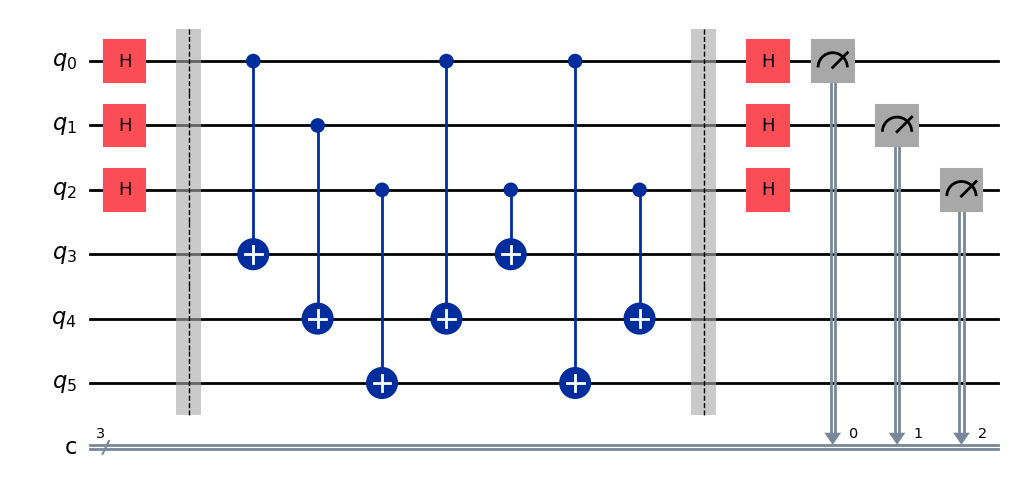

In [3]:
n = int(input("Enter number of qubits: "))
secret = input("Enter hidden period s: ")

circuit = QuantumCircuit(2*n, n)

# Step 1: superposition
circuit.h(range(n))
circuit.barrier()

# Step 2: oracle
circuit.compose(simon_oracle(n, secret), inplace=True)
circuit.barrier()

# Step 3: interference
circuit.h(range(n))

# measurement
circuit.measure(range(n), range(n))

# draw circuit
circuit.draw('mpl', filename="simon_circuit.png")

In [4]:
result = sim.run(transpile(circuit, sim), shots=1024).result()
counts = result.get_counts()
print("Measurement results:", counts)

Measurement results: {'101': 269, '000': 244, '010': 261, '111': 250}


In [5]:
from qiskit_ibm_runtime import SamplerV2 
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


In [6]:
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Load IBM account
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Select least busy real device
backend = service.least_busy(
    simulator=False,
    operational=True
)

print("Running on:", backend.name)

# Transpile circuit for target backend
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuit = pm.run(circuit)

# Create sampler
sampler = SamplerV2(mode=backend)

# Run job
job = sampler.run([isa_circuit], shots=1024)

print("Job ID:", job.job_id())

result = job.result()

# Extract counts
counts = result[0].data.c.get_counts()

print("Measurement results:")
print(counts)


qiskit_runtime_service.__init__:WARNING:2026-06-25 10:22:29,734: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-25 10:22:30,013: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-25 10:22:32,502: Using instance: open-instance, plan: open


Running on: ibm_kingston
Job ID: d8ujjb5posuc738q9f2g
Measurement results:
{'010': 243, '000': 239, '111': 232, '101': 249, '100': 20, '011': 13, '110': 12, '001': 16}


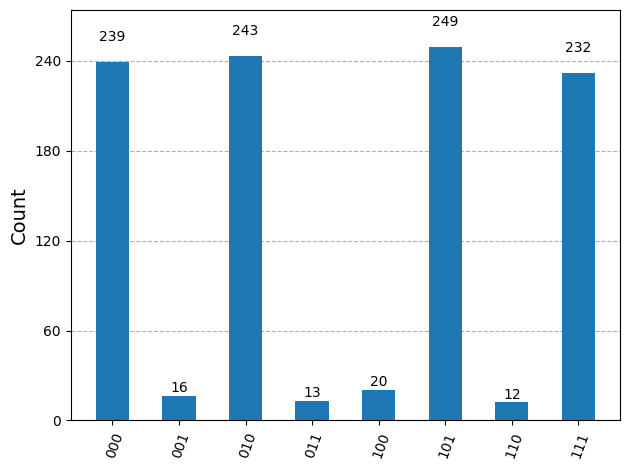

In [7]:
plot_histogram(counts)